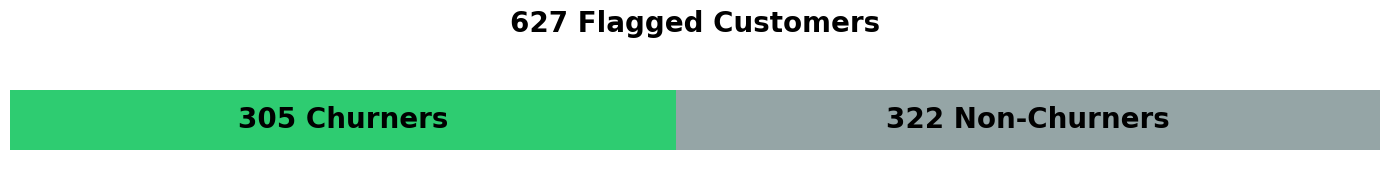

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Data
churners = 305
non_churners = 322
total = churners + non_churners

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 2))

# Create horizontal bar
ax.barh(0, churners, color='#2ecc71', height=0.5, left=0)
ax.barh(0, non_churners, color='#95a5a6', height=0.5, left=churners)

# Add labels inside the bars
ax.text(churners/2, 0, f'{churners} Churners', 
        ha='center', va='center', fontsize=20, fontweight='bold', color='black')
ax.text(churners + non_churners/2, 0, f'{non_churners} Non-Churners', 
        ha='center', va='center', fontsize=20, fontweight='bold', color='black')

# Formatting
ax.set_xlim(0, total)
ax.set_ylim(-0.5, 0.5)
ax.set_title('627 Flagged Customers', fontsize=20, fontweight='bold', pad=20)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Plot top predictors for churn from logistic regression model
# Excluding: Contract (1-year), Internet Service (Fiber Optic), Tenure Group (7-12 months), Streaming TV (No internet)

exclude_features = [
    'Contract (1-year)',
    'Internet Service (Fiber Optic)',
    'Tenure Group (7-12 months)',
    'Streaming TV (No internet)'
]

# Filter out excluded features
filtered_coef = coef_df_all_add_ons[~coef_df_all_add_ons['Feature'].isin(exclude_features)]
top_n = 10
top_coef = filtered_coef.head(top_n).copy()

plt.figure(figsize=(8, 6))  # Wide figure for more space
ax = sns.barplot(x='Coefficient', y='Feature', data=top_coef, palette='coolwarm', orient='h')
plt.title('Top Predictors of Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (Impact on Churn Risk)')
plt.ylabel('Feature')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Set x-limits to add more space for annotation text
xlim = ax.get_xlim()
x_pad = 0.1 * (xlim[1] - xlim[0])
plt.xlim(xlim[0] - x_pad, xlim[1] + x_pad)

# Annotate each bar with its coefficient value, always outside the bar
for bar, coef in zip(ax.patches, top_coef['Coefficient']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if x >= 0:
        text_x = x + 0.02 * (xlim[1] - xlim[0])
        ha = 'left'
    else:
        text_x = x - 0.02 * (xlim[1] - xlim[0])
        ha = 'right'
    ax.text(text_x, y, f'{coef:.2f}', va='center', ha=ha, color='black', fontsize=10, fontweight='bold', clip_on=False)

plt.tight_layout()
plt.savefig('../reports/figures/top_predictors_logreg_all_add_ons.png', bbox_inches='tight', dpi=300)
plt.show()